# Desafío: Enfermedad en la sangre

**Nombre:** Sasha Alcalá  G115  
**Fecha:** 04-05-2026  


In [1]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preparación y modelos
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# XGBoost
from xgboost import XGBClassifier

# Configuración visual
sns.set(style="whitegrid")

In [3]:
# Carga de datos
df = pd.read_csv("data/hcvdat0.csv")

df.head()

,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    str    
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    str    
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), str(2)
memory usage: 67.4 KB


In [6]:
df = df.drop(columns=["Unnamed: 0"])

In [7]:
df.shape

(615, 13)

In [8]:

df["target"] = np.where(df["Category"] == "0=Blood Donor", 0, 1)

df["suspect"] = np.where(
    df["Category"] == "0s=suspect Blood Donor", 1, 0
)

df.head()

,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,target,suspect
0,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,0,0
1,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,0,0
2,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,0,0
3,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,0,0
4,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,0,0


In [9]:
df = df.drop(columns=["Category"])

df.head()

,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,target,suspect
0,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,0,0
1,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,0,0
2,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,0,0
3,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,0,0
4,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,0,0


In [10]:
# codificar sexo
df["Sex"] = df["Sex"].map({"m": 1, "f": 0})

df.head()

,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,target,suspect
0,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,0,0
1,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,0,0
2,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,0,0
3,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,0,0
4,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,0,0


In [11]:
# revision valores nulos
missing = df.isna().mean() * 100
missing[missing > 0]

ALB     0.162602
ALP     2.926829
ALT     0.162602
CHOL    1.626016
PROT    0.162602
dtype: float64

In [12]:
# tratar valores ausentes según la regla del desafio
for col in df.columns:
    
    porcentaje_nulos = df[col].isna().mean() * 100
    
    if porcentaje_nulos > 0:
        
        # Si es menos de 1%, eliminar filas
        if porcentaje_nulos < 1:
            df = df.dropna(subset=[col])
            
        # Si es mayor a 1%, imputar promedio por target
        else:
            df[col] = df.groupby("target")[col].transform(
                lambda x: x.fillna(x.mean())
            )

df.isna().sum()

Age        0
Sex        0
ALB        0
ALP        0
ALT        0
AST        0
BIL        0
CHE        0
CHOL       0
CREA       0
GGT        0
PROT       0
target     0
suspect    0
dtype: int64

In [13]:
# analisis descriptivo
df.describe()

,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,target,suspect
count,612.000000,612.000000,612.000000,612.000000,612.000000,612.000000,612.000000,612.000000,612.000000,612.000000,612.000000,612.000000,612.000000,612.000000
mean,47.397059,0.611111,41.650000,68.285825,28.377124,34.629902,11.004902,8.206487,5.367106,81.258333,39.295752,72.047549,0.129085,0.011438
std,10.047230,0.487897,5.721926,25.702494,25.470818,33.010979,17.100164,2.193388,1.126548,49.858320,54.575007,5.391748,0.335568,0.106422
min,19.000000,0.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000,44.800000,0.000000,0.000000
25%,39.000000,0.000000,38.800000,52.900000,16.400000,21.600000,5.275000,6.937500,4.610000,67.000000,15.700000,69.300000,0.000000,0.000000
50%,47.000000,1.000000,41.950000,66.600000,22.950000,25.850000,7.300000,8.265000,5.300000,76.850000,23.300000,72.200000,0.000000,0.000000
75%,54.000000,1.000000,45.225000,79.375000,32.925000,32.825000,11.200000,9.600000,6.060000,88.000000,40.125000,75.400000,0.000000,0.000000
max,77.000000,1.000000,82.200000,416.600000,325.300000,324.000000,209.000000,16.410000,9.670000,1079.100000,650.900000,90.000000,1.000000,1.000000


In [14]:
df["target"].value_counts(normalize=True)

target
0    0.870915
1    0.129085
Name: proportion, dtype: float64

Luego de la limpieza de valores ausentes, la base queda con 612 registros. 
La variable objetivo presenta desbalance de clases: aproximadamente el 87% corresponde a donadores sanos (target = 0), mientras que cerca del 13% corresponde a posibles casos con enfermedad (target = 1). 
Por esta razón, al entrenar los modelos se debe considerar este desbalance, ya que un modelo podría tender a predecir mayoritariamente la clase sana.

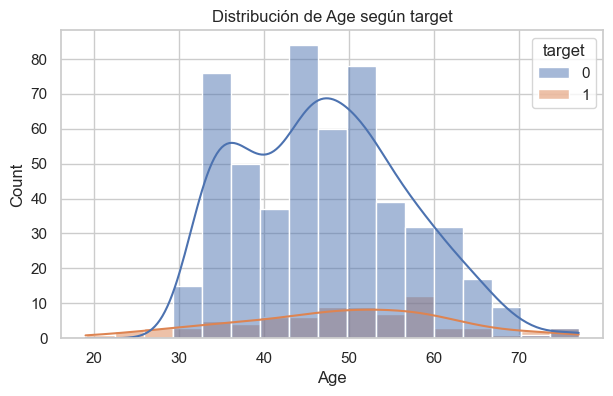

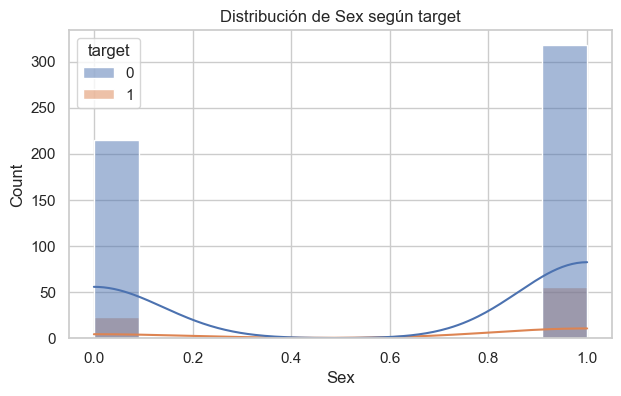

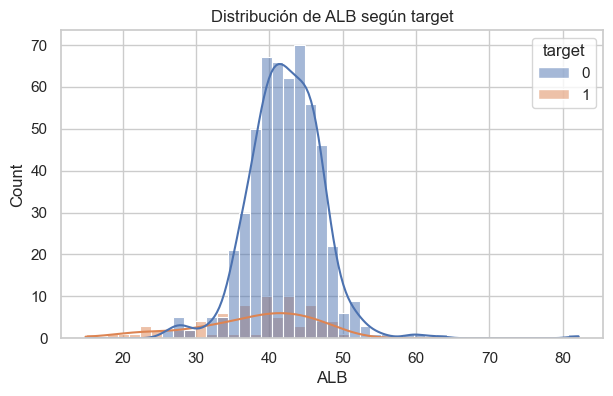

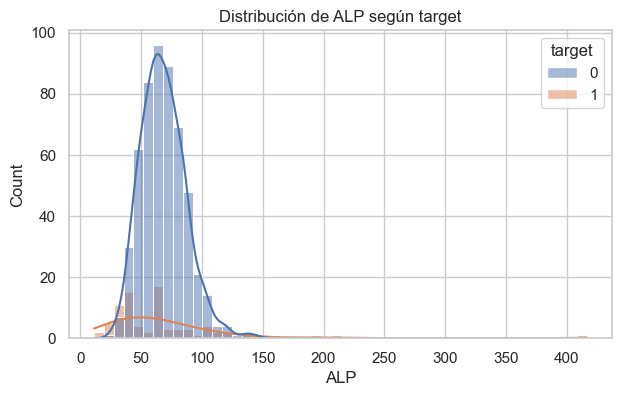

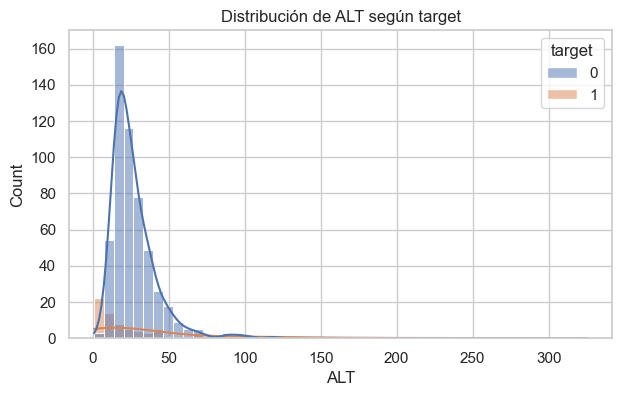

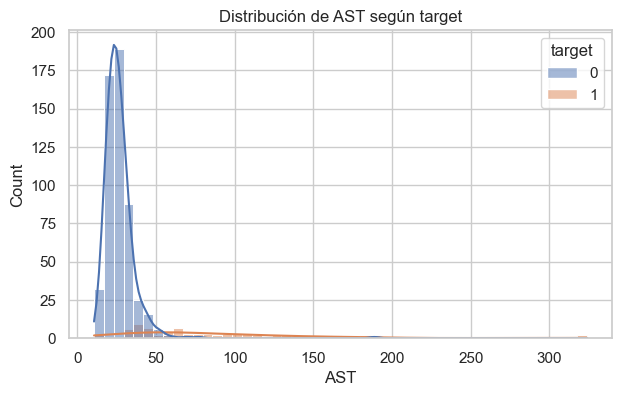

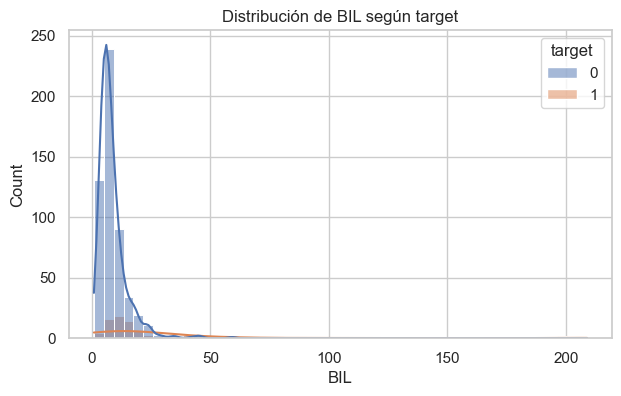

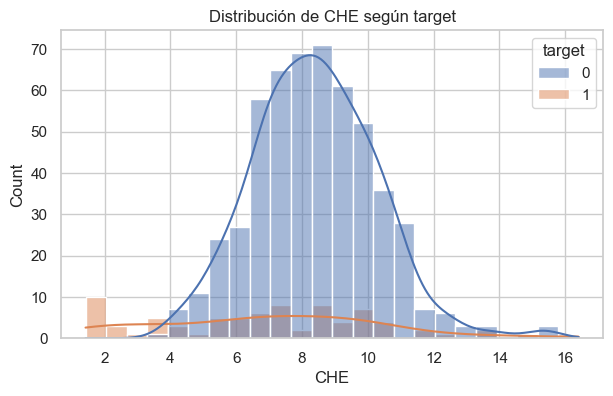

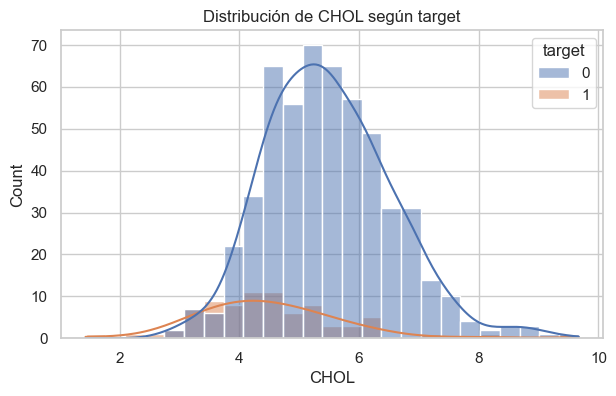

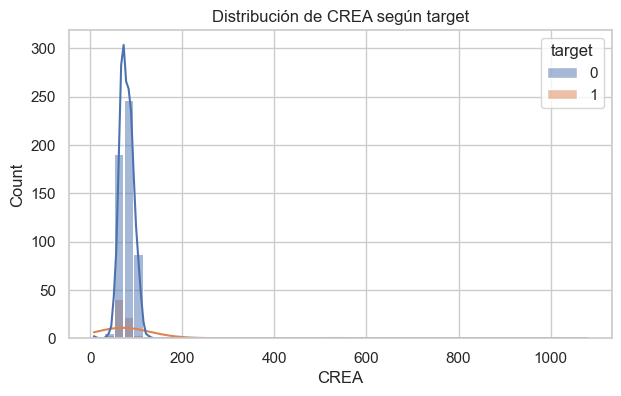

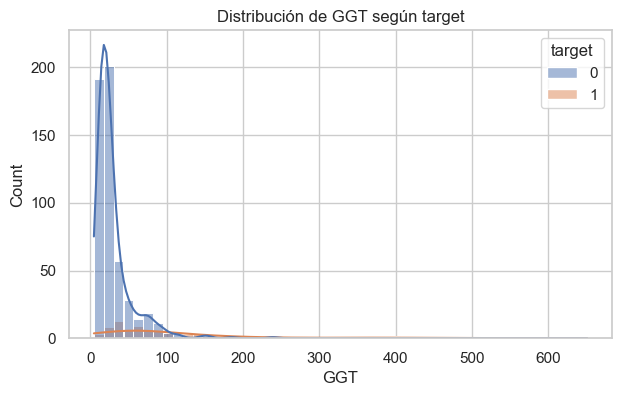

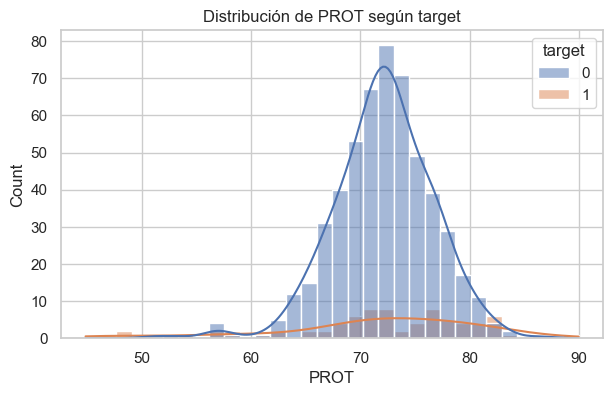

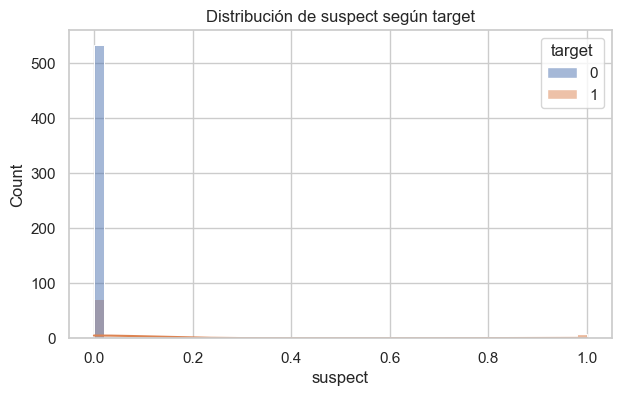

In [15]:
# graficos de distrubucion
variables = df.drop(columns=["target"]).columns

for col in variables:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, hue="target", kde=True)
    plt.title(f"Distribución de {col} según target")
    plt.show()

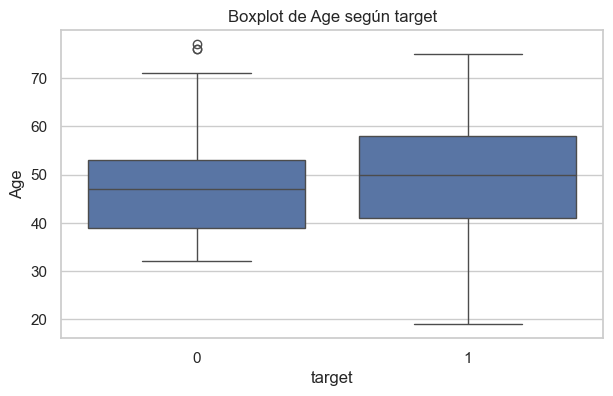

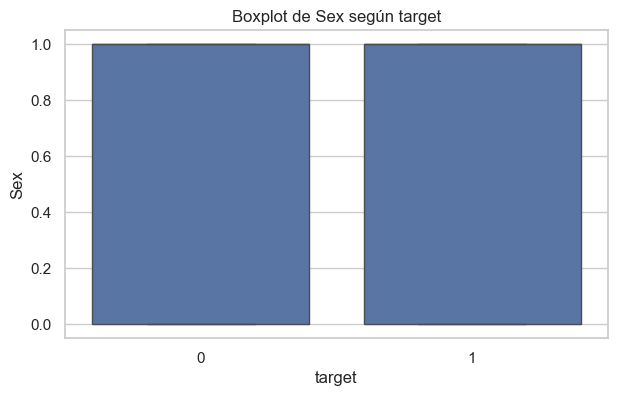

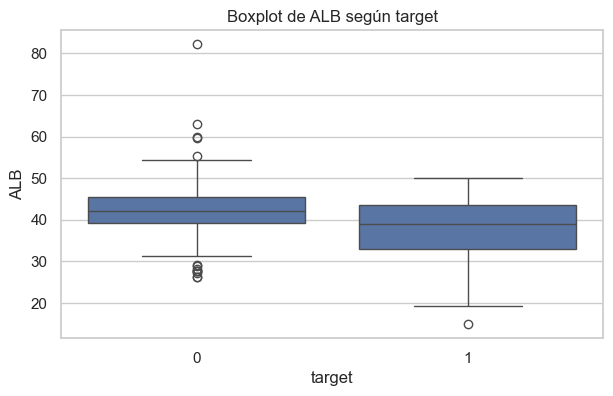

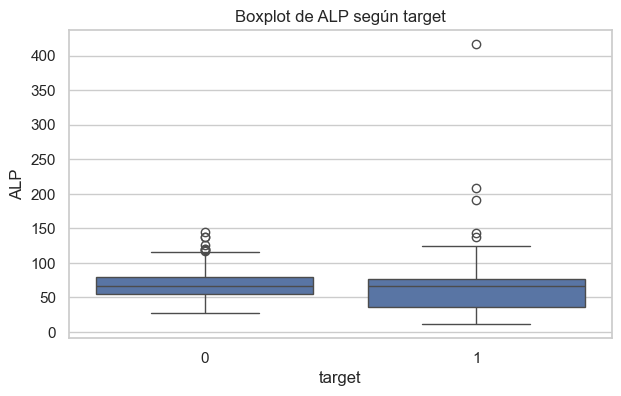

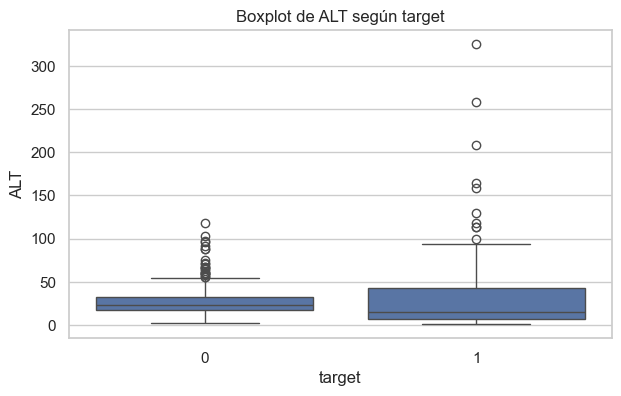

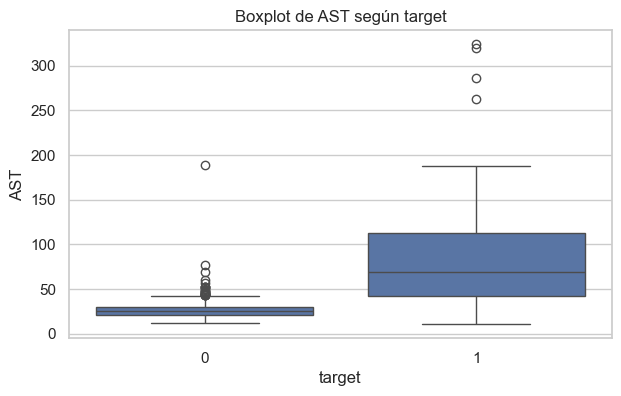

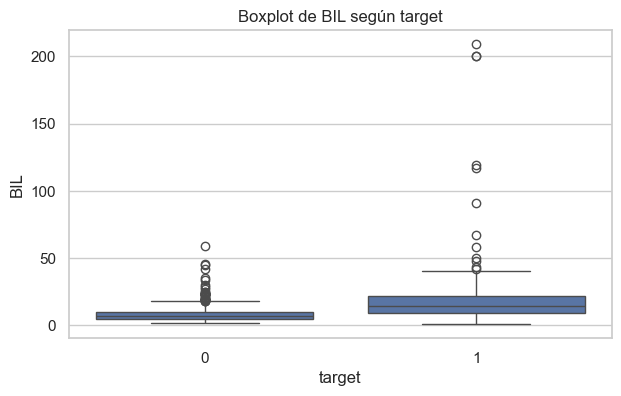

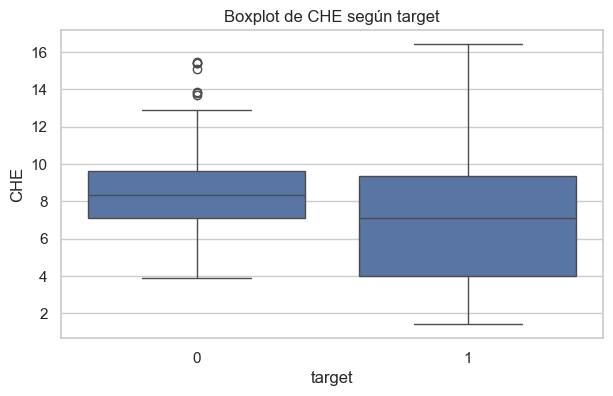

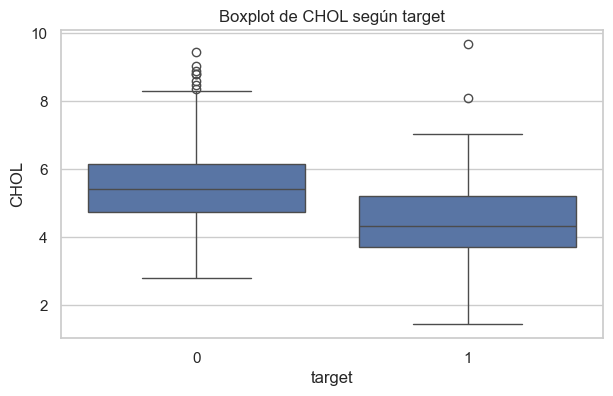

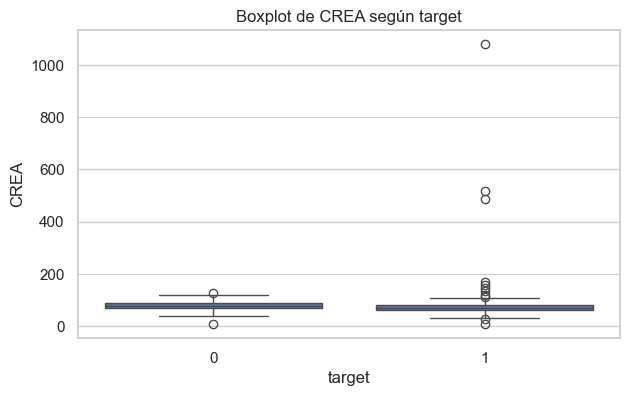

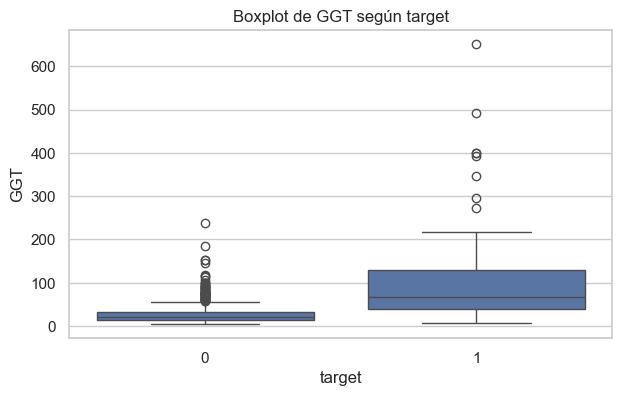

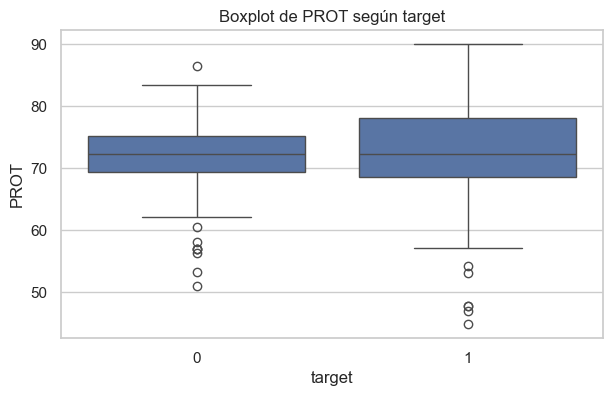

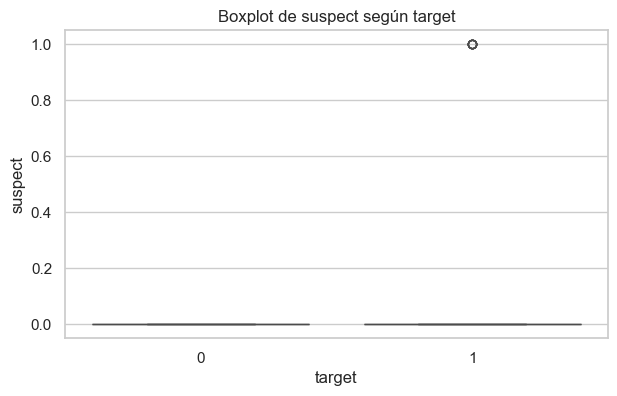

In [16]:
# boxplots para outliers
for col in variables:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="target", y=col)
    plt.title(f"Boxplot de {col} según target")
    plt.show()

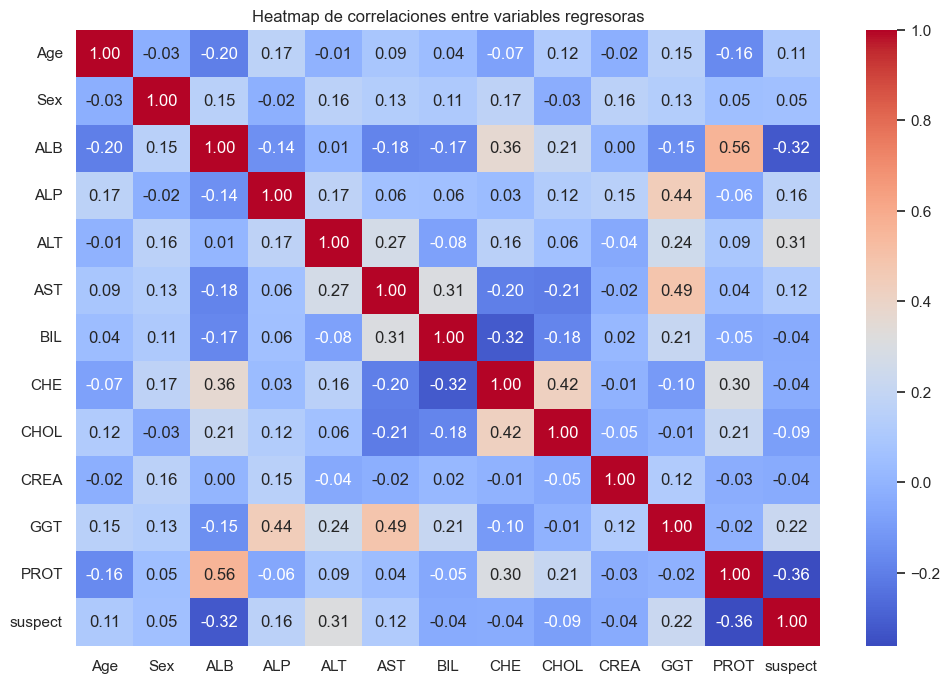

In [17]:
# heatmap de correlacion
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop(columns=["target"]).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap de correlaciones entre variables regresoras")
plt.show()

El heatmap muestra que, en general, las variables presentan correlaciones bajas y moderadas, por lo que no se observa una multicolinealidad extrema.

Las relaciones más destacadas son:

- ALB y PROT (0.56)
- AST y GGT (0.49)
- CHE y CHOL (0.42)

Además, algunas variables muestran correlaciones negativas moderadas con la variable suspect, como ALB (-0.32) y PROT (-0.36).

Debido a que existen algunas relaciones entre variables predictoras, el uso de técnicas de regularización como Elastic Net resulta útil para reducir sobreajuste y mejorar la capacidad de generalización del modelo.

In [18]:
# separar x y y
X = df.drop(columns=["target"])
y = df["target"]

X.head()

,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,suspect
0,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,0
1,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,0
2,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,0
3,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,0
4,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,0


In [19]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

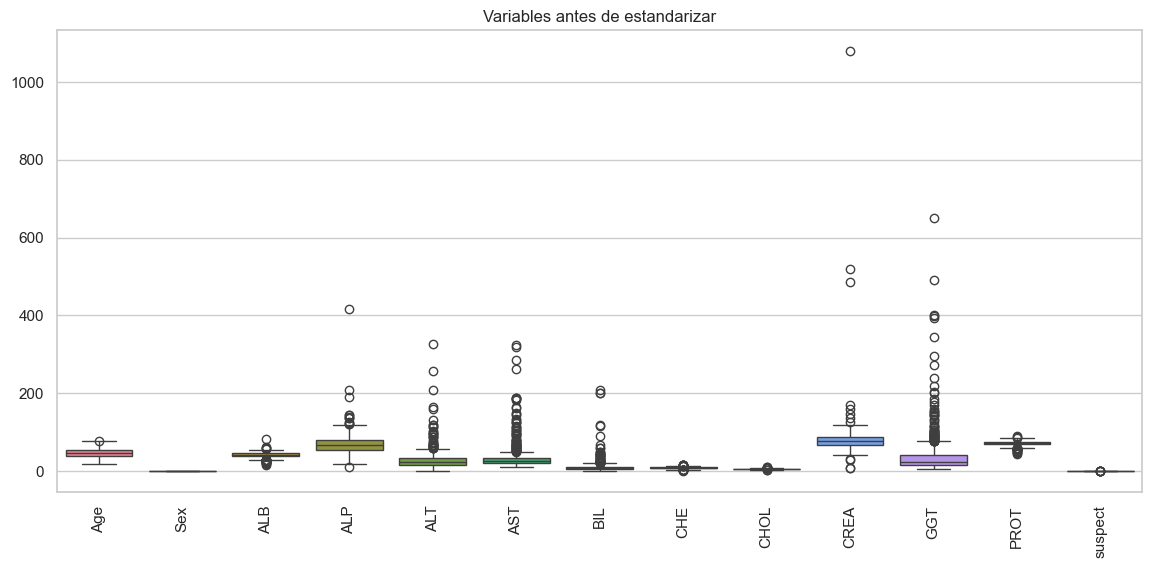

In [20]:
# antes de estandarizar: boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=X)
plt.xticks(rotation=90)
plt.title("Variables antes de estandarizar")
plt.show()

El boxplot previo a la estandarización muestra que las variables presentan escalas muy diferentes.

Por ejemplo, CREA y GGT poseen rangos considerablemente mayores que otras variables como Sex o CHE.

Además, se observan múltiples valores extremos (outliers), especialmente en variables como CREA, GGT, AST y ALP.

Debido a estas diferencias de escala, se vuelve necesario aplicar estandarización antes de entrenar modelos regularizados como Elastic Net, para evitar que ciertas variables dominen el proceso de aprendizaje únicamente por su magnitud.

In [ ]:
# train/test split y estandarizacion
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# separa 67% entrenamiento y 33% test, como pide el desafío. Luego estandariza usando media 0 y desviación estándar 1.

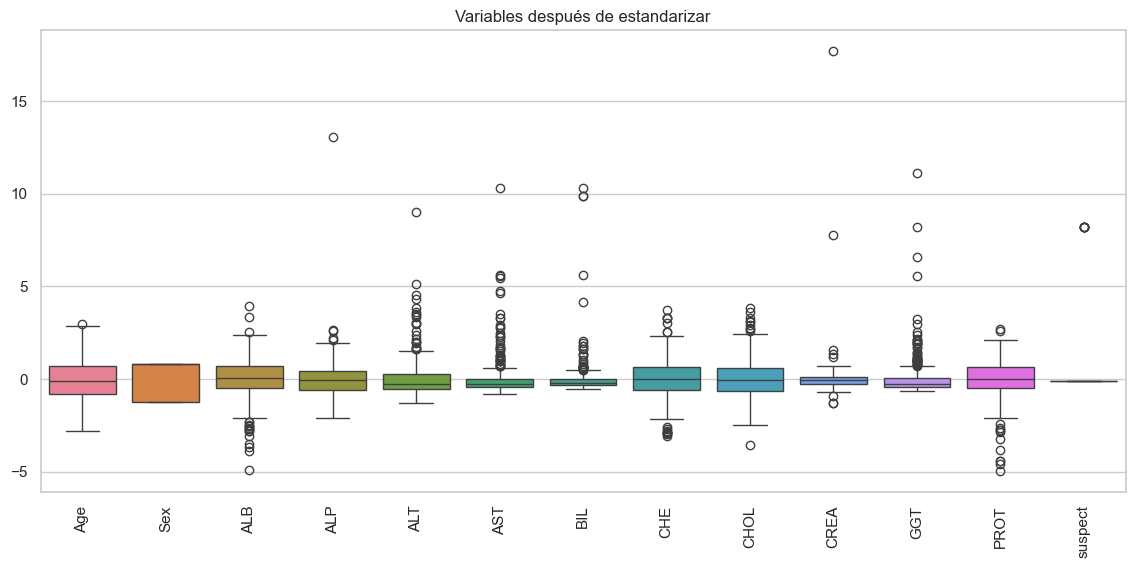

In [22]:
# estandarizar: boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=X_train_scaled_df)
plt.xticks(rotation=90)
plt.title("Variables después de estandarizar")
plt.show()

Después de aplicar StandardScaler, todas las variables quedaron centradas alrededor de cero y con escalas comparables.

Esto corrige el problema observado previamente, donde algunas variables como CREA y GGT presentaban magnitudes mucho mayores que otras.

Aún se observan algunos valores extremos, sin embargo estos fueron conservados debido a que en un contexto clínico podrían representar casos reales de pacientes con alteraciones significativas.

La estandarización mejora el desempeño de modelos sensibles a la escala, como Elastic Net.

### 2- Regresión Logística Elastic Net ###
Entrenar Elastic Net con validación cruzada

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

elastic_model = LogisticRegressionCV(
    Cs=np.linspace(0.01, 5.0, 200),
    penalty="elasticnet",
    solver="saga",
    l1_ratios=np.linspace(0, 1, 200),
    cv=cv,
    scoring="f1",
    max_iter=10000,
    random_state=42,
    class_weight="balanced"
)

elastic_model.fit(X_train_scaled, y_train)

# entrena una regresión logística regularizada con Elastic Net usando 5-fold cross validation.

d:\Data Science\GitHub\desafio _enfermedad_en_la_sangre\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
d:\Data Science\GitHub\desafio _enfermedad_en_la_sangre\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  w

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.","array([0.01 ..., 5. ])"
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","array([0. ..., 1. ])"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'f1'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification b

In [24]:
# mejores hiperparámetros Elastic Net
print("Mejor C:", elastic_model.C_[0])
print("Mejor l1_ratio:", elastic_model.l1_ratio_[0])

Mejor C: 0.060150753768844226
Mejor l1_ratio: 0.020100502512562814


In [25]:
# evaluar Elastic Net
y_pred_elastic = elastic_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_elastic))

metricas_elastic = {
    "modelo": "Elastic Net Logistic Regression",
    "accuracy": accuracy_score(y_test, y_pred_elastic),
    "precision": precision_score(y_test, y_pred_elastic),
    "recall": recall_score(y_test, y_pred_elastic),
    "f1_score": f1_score(y_test, y_pred_elastic)
}

metricas_elastic

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       176
           1       0.96      0.85      0.90        26

    accuracy                           0.98       202
   macro avg       0.97      0.92      0.94       202
weighted avg       0.97      0.98      0.97       202



{'modelo': 'Elastic Net Logistic Regression',
 'accuracy': 0.9752475247524752,
 'precision': 0.9565217391304348,
 'recall': 0.8461538461538461,
 'f1_score': 0.8979591836734694}

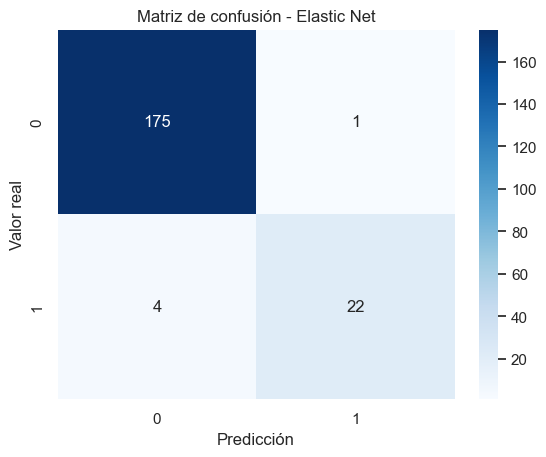

In [26]:
# matriz de confusión Elastic Net
cm = confusion_matrix(y_test, y_pred_elastic)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Elastic Net")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [27]:
# importancia de variables en Elastic Net
coeficientes = pd.DataFrame({
    "variable": X.columns,
    "coeficiente": elastic_model.coef_[0],
    "importancia_abs": np.abs(elastic_model.coef_[0])
}).sort_values(by="importancia_abs", ascending=False)

coeficientes

,variable,coeficiente,importancia_abs
5,AST,1.097213,1.097213
10,GGT,0.901700,0.901700
3,ALP,-0.734115,0.734115
12,suspect,0.550981,0.550981
8,CHOL,-0.448395,0.448395
6,BIL,0.375734,0.375734
2,ALB,-0.352298,0.352298
11,PROT,0.322385,0.322385
9,CREA,0.301504,0.301504
4,ALT,-0.168290,0.168290


In [28]:
coeficientes.head(3)

,variable,coeficiente,importancia_abs
5,AST,1.097213,1.097213
10,GGT,0.901700,0.901700
3,ALP,-0.734115,0.734115


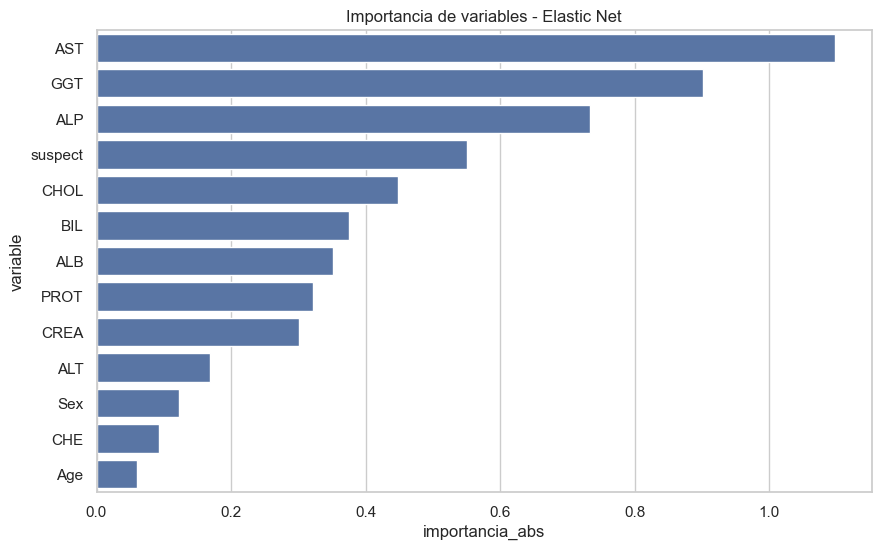

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(data=coeficientes, x="importancia_abs", y="variable")
plt.title("Importancia de variables - Elastic Net")
plt.show()

El modelo Elastic Net obtuvo un accuracy de 97.5%, mostrando un rendimiento general muy alto.

La métrica precision fue de 95.6%, indicando que cuando el modelo predice enfermedad suele acertar correctamente.

El recall fue de 84.6%, lo que significa que aún existen algunos casos de pacientes enfermos que no fueron detectados.

El F1-score alcanzó 89.8%, siendo una métrica relevante debido al desbalance presente en la variable objetivo.

Las variables más importantes para la predicción fueron AST, GGT y ALP, todas relacionadas con biomarcadores hepáticos, lo que resulta coherente con el problema clínico analizado.

Además, la variable suspect también mostró relevancia dentro del modelo.

### 3- XGBoost ###
Entrenar XGBoost con GridSearchCV

In [30]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

param_grid = {
    "reg_lambda": np.linspace(0.0, 2.0, 10),
    "reg_alpha": np.linspace(0.0, 1.0, 10),
    "learning_rate": np.linspace(0.1, 10, 20)
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_xgb.fit(X_train_scaled, y_train)

# prueba combinaciones de hiperparámetros para encontrar el mejor XGBoost según F1-score

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': array([ 0.1 ... 10. ]), 'reg_alpha': array([0. ..., 1. ]), 'reg_lambda': array([0. ..., 2. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

In [31]:
# mejores hiperparámetros XGBoost
grid_xgb.best_params_

{'learning_rate': np.float64(1.6631578947368424),
 'reg_alpha': np.float64(0.0),
 'reg_lambda': np.float64(1.3333333333333333)}

In [32]:
grid_xgb.best_score_

np.float64(0.8762042788129744)

In [33]:
# evaluar XGBoost
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test_scaled)

print(classification_report(y_test, y_pred_xgb))

metricas_xgb = {
    "modelo": "XGBoost",
    "accuracy": accuracy_score(y_test, y_pred_xgb),
    "precision": precision_score(y_test, y_pred_xgb),
    "recall": recall_score(y_test, y_pred_xgb),
    "f1_score": f1_score(y_test, y_pred_xgb)
}

metricas_xgb

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       176
           1       0.96      0.88      0.92        26

    accuracy                           0.98       202
   macro avg       0.97      0.94      0.95       202
weighted avg       0.98      0.98      0.98       202



{'modelo': 'XGBoost',
 'accuracy': 0.9801980198019802,
 'precision': 0.9583333333333334,
 'recall': 0.8846153846153846,
 'f1_score': 0.92}

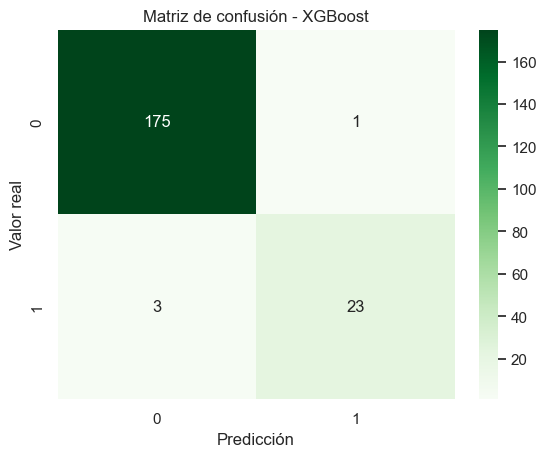

In [34]:
# matriz de confusión XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusión - XGBoost")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [35]:
# importancia de variables XGBoost
importancias_xgb = pd.DataFrame({
    "variable": X.columns,
    "importancia": best_xgb.feature_importances_
}).sort_values(by="importancia", ascending=False)

importancias_xgb

,variable,importancia
5,AST,0.631272
4,ALT,0.132752
3,ALP,0.074075
8,CHOL,0.072044
10,GGT,0.044963
11,PROT,0.013419
6,BIL,0.011210
9,CREA,0.009432
0,Age,0.008265
2,ALB,0.002565


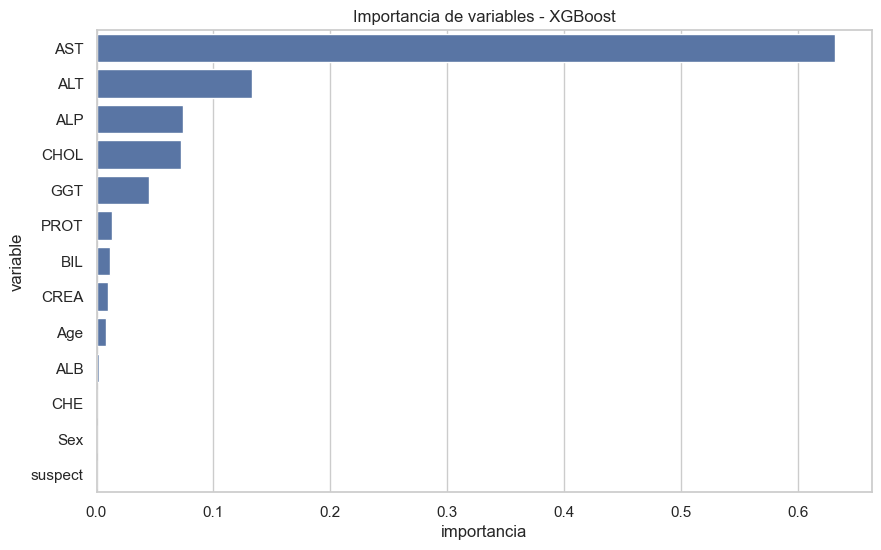

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importancias_xgb, x="importancia", y="variable")
plt.title("Importancia de variables - XGBoost")
plt.show()

### 4- Comparación final de modelos ###


In [37]:
comparacion = pd.DataFrame([metricas_elastic, metricas_xgb])
comparacion

,modelo,accuracy,precision,recall,f1_score
0,Elastic Net Logistic Regression,0.975248,0.956522,0.846154,0.897959
1,XGBoost,0.980198,0.958333,0.884615,0.920000


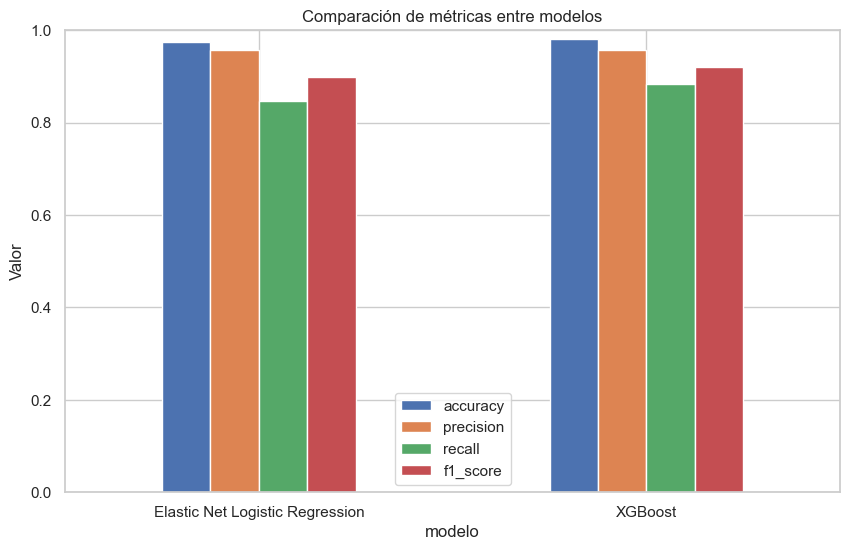

In [38]:
comparacion.set_index("modelo")[["accuracy", "precision", "recall", "f1_score"]].plot(kind="bar", figsize=(10, 6))
plt.title("Comparación de métricas entre modelos")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

El gráfico comparativo confirma que ambos modelos presentan un rendimiento alto.

Sin embargo, XGBoost supera levemente a Elastic Net en todas las métricas evaluadas.

La diferencia más relevante se observa en recall, donde XGBoost logra identificar una mayor cantidad de pacientes realmente enfermos.

Dado que en problemas médicos es prioritario reducir falsos negativos, XGBoost se selecciona como el mejor modelo para este problema.

Elastic Net también mostró un excelente desempeño y mantiene la ventaja de ser más interpretable.